#Project Title

## Telangana Climate Zone Segmentation Analysis

#Domain: Agricultural Climate Analytics

This project helps farmers know exactly which crops to plant when as we have figured out 4 different climate zones across Telangana.

#Objective

1. Identify the 4 climatic zones across Telangana to support crop selection and planting for farmers.
2. Study rainfall, temperature, and humidity patterns over seasons to spot trends that impact crop decisions.
3. Analyze 2024 – 2025 weather trends to understand seasonality, severe weather events (eg: floods), and agricultural impacts.
4. Turn data into farmer-friendly insights for better crop planning, water management, and bad weather protection.

# Dataset Information

*   Source: Telangana State Open Weather Data via Hugging Face.
*   Location: Telangana (District Level - daily data).
*   Timeline: Data collected during the period 2024 - 2025

#**Stage 1**

#Problem Definition

*   Telangana's 33 districts face different weather patterns, but farmers lack clear guidance on crop selection, planting, irrigation, and weather risks.

*   Daily weather data (2024-2025) exists but remains fragmented and unusable for district-level farming decisions.

*   This project uses Python data analysis to aggregate, cluster, and visualize the data - delivering 4 distinct climate zones and actionable farming insights.

#Data Selection

In [ ]:
# Importing Libraries

# Data manipulation libraries
import pandas as pd          # For cleaning and analysing the weather data
import numpy as np           # For numerical operations

# Visualization libraries
import matplotlib.pyplot as plt           # For plotting charts and graphs
import seaborn as sns                     # For advanced visualization

import warnings
warnings.filterwarnings('ignore')       # For keeping output clean without future warnings

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# Loading dataset

url="https://raw.githubusercontent.com/DataCognito/Telangana-Climate-Analytics/refs/heads/main/telangana_weather_data.csv"
df = pd.read_csv(url)        # Loads the data directly into dataframe

print("Dataset Loaded Successfully!")


Dataset Loaded Successfully!


# Dataset Description

Initial EDA (head, info, describe, shape, null checks, duplicate check)

In [ ]:
print(df.head())     # prints first 5 rows

   District          Mandal       Date  Rain (mm)  Min Temp (°C)  \
0  Adilabad  Adilabad Rural  01-Jan-24        0.0           14.0   
1  Adilabad  Adilabad Rural  02-Jan-24        0.0           14.6   
2  Adilabad  Adilabad Rural  03-Jan-24        0.0           17.2   
3  Adilabad  Adilabad Rural  04-Jan-24        0.0           19.6   
4  Adilabad  Adilabad Rural  05-Jan-24        0.0           16.5   

   Max Temp (°C)  Min Humidity (%)  Max Humidity (%)  Min Wind Speed (Kmph)  \
0           28.7              53.0              99.4                    0.0   
1           30.5              51.6              98.7                    0.0   
2           28.9              50.4              92.1                    0.0   
3           30.1              53.0              83.3                    0.0   
4           30.5              45.1              87.3                    0.0   

   Max Wind Speed (Kmph)  
0                   10.4  
1                    7.0  
2                   10.5  
3       

In [ ]:
print(df.info())       # Data overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242964 entries, 0 to 242963
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   District               242964 non-null  object 
 1   Mandal                 242964 non-null  object 
 2   Date                   242964 non-null  object 
 3   Rain (mm)              242964 non-null  float64
 4   Min Temp (°C)          242964 non-null  float64
 5   Max Temp (°C)          242964 non-null  float64
 6   Min Humidity (%)       242964 non-null  float64
 7   Max Humidity (%)       242964 non-null  float64
 8   Min Wind Speed (Kmph)  242964 non-null  float64
 9   Max Wind Speed (Kmph)  242964 non-null  float64
dtypes: float64(7), object(3)
memory usage: 18.5+ MB
None


In [ ]:
print(df.describe())    # Data description

           Rain (mm)  Min Temp (°C)  Max Temp (°C)  Min Humidity (%)  \
count  242964.000000  242964.000000  242964.000000     242964.000000   
mean        2.773735      21.668655      34.250396         49.061703   
std        10.489075       4.145564       4.016734         18.322837   
min         0.000000       5.200000      -1.000000          0.000000   
25%         0.000000      18.800000      31.500000         35.500000   
50%         0.000000      22.700000      33.700000         48.000000   
75%         0.000000      24.500000      36.700000         62.100000   
max       456.500000      35.300000      47.200000         99.900000   

       Max Humidity (%)  Min Wind Speed (Kmph)  Max Wind Speed (Kmph)  
count     242964.000000          242964.000000          242964.000000  
mean          91.142822               0.242282               8.209577  
std           11.320325               0.940987               5.165144  
min            0.000000               0.000000               0.

In [ ]:
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")         # prints total number of rows & columns

Rows: 242,964, Columns: 10


In [ ]:
null_counts = df.isnull().sum()
print(null_counts)                   # prints null count for each columns

District                 0
Mandal                   0
Date                     0
Rain (mm)                0
Min Temp (°C)            0
Max Temp (°C)            0
Min Humidity (%)         0
Max Humidity (%)         0
Min Wind Speed (Kmph)    0
Max Wind Speed (Kmph)    0
dtype: int64


In [ ]:
print(f"Duplicate rows: {df.duplicated().sum():,}")      # Checks duplicate rows

Duplicate rows: 0


# **Stage 2**

#Data Cleaning & Preprocessing

In [ ]:
df.columns.tolist()  # shows all column names

['District',
 'Mandal',
 'Date',
 'Rain (mm)',
 'Min Temp (°C)',
 'Max Temp (°C)',
 'Min Humidity (%)',
 'Max Humidity (%)',
 'Min Wind Speed (Kmph)',
 'Max Wind Speed (Kmph)']

#Removal of Column

In [ ]:
# Remove Mandal column - Focus on District-level analysis
df = df.drop('Mandal', axis=1)
print("After removing Mandal column:")
print(f"Columns: {list(df.columns)}")


After removing Mandal column:
Columns: ['District', 'Date', 'Rain (mm)', 'Min Temp (°C)', 'Max Temp (°C)', 'Min Humidity (%)', 'Max Humidity (%)', 'Min Wind Speed (Kmph)', 'Max Wind Speed (Kmph)']


# Converting Data type

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])    # Converts date to datetime
print("Date converted to datetime!")

print(df.dtypes)  # Verify: Date = datetime

Date converted to datetime!
District                         object
Date                     datetime64[ns]
Rain (mm)                       float64
Min Temp (°C)                   float64
Max Temp (°C)                   float64
Min Humidity (%)                float64
Max Humidity (%)                float64
Min Wind Speed (Kmph)           float64
Max Wind Speed (Kmph)           float64
dtype: object


#Adding Extra Columns

In [ ]:
df['Month'] = df['Date'].dt.month_name()

In [ ]:
print(df['Month'].value_counts().head())

Month
January     37944
March       18972
July        18972
May         18972
December    18972
Name: count, dtype: int64


In [ ]:
def temp_category(temp):
    if temp >= 38: return 'Extreme'
    elif temp >= 35: return 'Very Hot'
    elif temp >= 32: return 'Hot'
    else: return 'Normal'

df['Temp_Category'] = df['Max Temp (°C)'].apply(temp_category)

In [ ]:
print(df['Temp_Category'].value_counts().head())

Temp_Category
Hot         79043
Normal      72072
Very Hot    45974
Extreme     45875
Name: count, dtype: int64


In [ ]:
# Heat Index (Temp + Humidity interaction)
df['Heat_Index'] = df['Max Temp (°C)'] + (df['Max Humidity (%)'] / 100 * 5)

In [ ]:
print(df['Heat_Index'].value_counts().head())

Heat_Index
37.8    1285
37.9    1281
37.5    1196
38.0    1134
37.7    1121
Name: count, dtype: int64


In [ ]:
df.columns.tolist()

['District',
 'Date',
 'Rain (mm)',
 'Min Temp (°C)',
 'Max Temp (°C)',
 'Min Humidity (%)',
 'Max Humidity (%)',
 'Min Wind Speed (Kmph)',
 'Max Wind Speed (Kmph)',
 'Month',
 'Temp_Category',
 'Heat_Index']

In [ ]:
print("Month:", df['Month'].nunique())

Month: 12


In [ ]:
print("Temp_Category:", df['Temp_Category'].nunique())

Temp_Category: 4


In [ ]:
print("Heat_Index:", df['Heat_Index'].nunique())

Heat_Index: 7533


In [ ]:
col = 'Max Temp (°C)'
minus_one_count = (df[col] == -1).sum()        # Counts the -1 values in Max Temp column
print(f"-1 values in Max Temp: {minus_one_count}")

-1 values in Max Temp: 2


In [ ]:
# -1 values in 'Max Temp (°C)' with Median imputation
median_max_temp = df[df['Max Temp (°C)'] != -1]['Max Temp (°C)'].median()
df['Max Temp (°C)'] = df['Max Temp (°C)'].replace(-1, median_max_temp)

# Check the count of -1 values after replacement
minus_one_count_final = (df['Max Temp (°C)'] == -1).sum()
print(f"-1 values in 'Max Temp (°C)' after replacement: {minus_one_count_final}")

-1 values in 'Max Temp (°C)' after replacement: 0


In [ ]:
col = 'Max Temp (°C)'
print(df[col].describe())

count    242964.000000
mean         34.250682
std           4.015460
min          21.200000
25%          31.500000
50%          33.700000
75%          36.700000
max          47.200000
Name: Max Temp (°C), dtype: float64


In [ ]:
col = 'Max Humidity (%)'
median_max_hum = df[col].replace(0, float('nan')).median()
df[col] = df[col].replace(0, median_max_hum)       # replaces 0 values in max humidity

In [ ]:
col = 'Max Humidity (%)'
print(df[col].describe())

count    242964.000000
mean         91.146748
std          11.305246
min          20.700000
25%          86.900000
50%          95.400000
75%         100.000000
max         100.000000
Name: Max Humidity (%), dtype: float64


In [ ]:
print(f"Max Temp -1 count: {(df['Max Temp (°C)'] == -1).sum()}")
print(f"Max Humidity 0% count: {(df['Max Humidity (%)'] == 0).sum()}")

Max Temp -1 count: 0
Max Humidity 0% count: 0


In [ ]:
print(f"Duplicate rows: {df.duplicated().sum():,}")      # Checks duplicate rows

Duplicate rows: 136


In [ ]:
df = df.drop_duplicates()
print(f"Duplicate rows after removal: {df.duplicated().sum():,}")      # Removes duplicate rows

Duplicate rows after removal: 0


In [ ]:
df.columns.tolist()

['District',
 'Date',
 'Rain (mm)',
 'Min Temp (°C)',
 'Max Temp (°C)',
 'Min Humidity (%)',
 'Max Humidity (%)',
 'Min Wind Speed (Kmph)',
 'Max Wind Speed (Kmph)',
 'Month',
 'Temp_Category',
 'Heat_Index']

# **Stage 3**

# EDA , Statistical analysis & Visualizations


**Exploratory Data Analysis (EDA)**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242828 entries, 0 to 242963
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   District               242828 non-null  object        
 1   Date                   242828 non-null  datetime64[ns]
 2   Rain (mm)              242828 non-null  float64       
 3   Min Temp (°C)          242828 non-null  float64       
 4   Max Temp (°C)          242828 non-null  float64       
 5   Min Humidity (%)       242828 non-null  float64       
 6   Max Humidity (%)       242828 non-null  float64       
 7   Min Wind Speed (Kmph)  242828 non-null  float64       
 8   Max Wind Speed (Kmph)  242828 non-null  float64       
 9   Month                  242828 non-null  object        
 10  Temp_Category          242828 non-null  object        
 11  Heat_Index             242828 non-null  float64       
dtypes: datetime64[ns](1), float64(8), object(3)
memor

In [ ]:
df.describe()

,Date,Rain (mm),Min Temp (°C),Max Temp (°C),Min Humidity (%),Max Humidity (%),Min Wind Speed (Kmph),Max Wind Speed (Kmph),Heat_Index
count,242828,242828.000000,242828.000000,242828.000000,242828.000000,242828.000000,242828.000000,242828.000000,242828.000000
mean,2024-07-16 23:54:58.275322368,2.775289,21.669037,34.251000,49.058646,91.145426,0.242409,8.212108,38.807789
min,2024-01-01 00:00:00,0.000000,5.200000,21.200000,0.000000,20.700000,0.000000,0.000000,2.795000
25%,2024-04-09 00:00:00,0.000000,18.800000,31.500000,35.500000,86.900000,0.000000,5.000000,36.210000
50%,2024-07-17 00:00:00,0.000000,22.700000,33.700000,48.000000,95.400000,0.000000,7.900000,38.400000
75%,2024-10-24 00:00:00,0.000000,24.500000,36.700000,62.100000,100.000000,0.000000,11.100000,41.230000
max,2025-01-31 00:00:00,456.500000,35.300000,47.200000,99.900000,100.000000,28.800000,69.900000,51.500000
std,NaN,10.491806,4.145598,4.015693,18.324954,11.307528,0.941226,5.164594,3.750149


In [ ]:
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")         # prints total number of rows & columns

Rows: 242,828, Columns: 12


# **Statistical Analysis for Numerical Columns**

# Mesasure Of Central Tendency

In [ ]:
# Central Tendency
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
central_tendency = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0]
}).round(2)

print("\n=== CENTRAL TENDENCY SUMMARY ===")
print(central_tendency)


=== CENTRAL TENDENCY SUMMARY ===
                        Mean  Median   Mode
Rain (mm)               2.78     0.0    0.0
Min Temp (°C)          21.67    22.7   23.6
Max Temp (°C)          34.25    33.7   32.9
Min Humidity (%)       49.06    48.0   56.5
Max Humidity (%)       91.15    95.4  100.0
Min Wind Speed (Kmph)   0.24     0.0    0.0
Max Wind Speed (Kmph)   8.21     7.9    0.0
Heat_Index             38.81    38.4   37.8


# Variance and Standard Deviation

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

dispersion = pd.DataFrame({
    'Variance': df[numeric_cols].var(),
    'Std_Dev': df[numeric_cols].std()
}).round(2)

print("\n=== DISPERSION SUMMARY ===")
print(dispersion)


=== DISPERSION SUMMARY ===
                       Variance  Std_Dev
Rain (mm)                110.08    10.49
Min Temp (°C)             17.19     4.15
Max Temp (°C)             16.13     4.02
Min Humidity (%)         335.80    18.32
Max Humidity (%)         127.86    11.31
Min Wind Speed (Kmph)      0.89     0.94
Max Wind Speed (Kmph)     26.67     5.16
Heat_Index                14.06     3.75


# Coefficient of Variation (Relative Spread)

In [ ]:
# CV = Std_Dev / Mean * 100 (compares variability across different scales)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\n=== COEFFICIENT OF VARIATION (CV%) ===")
cv_percent = (df[numeric_cols].std() / df[numeric_cols].mean() * 100).round(2)
print(cv_percent.sort_values(ascending=False))



=== COEFFICIENT OF VARIATION (CV%) ===
Min Wind Speed (Kmph)    388.28
Rain (mm)                378.04
Max Wind Speed (Kmph)     62.89
Min Humidity (%)          37.35
Min Temp (°C)             19.13
Max Humidity (%)          12.41
Max Temp (°C)             11.72
Heat_Index                 9.66
dtype: float64


In [ ]:
import scipy.stats as stats

numeric_cols = df.select_dtypes(include='number').columns

print("=== SKEWNESS & KURTOSIS ===")

# Skewness (asymmetry): >0 right tail, <0 left tail
skewness = df[numeric_cols].skew()
print("\nSKEWNESS (Shape):")
print(skewness.round(2))

# Kurtosis (tails/outliers): >3 heavy tails, <3 light tails
kurtosis = df[numeric_cols].kurtosis()
print("\nKURTOSIS (Tails):")
print(kurtosis.round(2))

=== SKEWNESS & KURTOSIS ===

SKEWNESS (Shape):
Rain (mm)                9.30
Min Temp (°C)           -0.62
Max Temp (°C)            0.40
Min Humidity (%)         0.21
Max Humidity (%)        -1.71
Min Wind Speed (Kmph)    6.03
Max Wind Speed (Kmph)    1.37
Heat_Index               0.25
dtype: float64

KURTOSIS (Tails):
Rain (mm)                169.62
Min Temp (°C)             -0.03
Max Temp (°C)             -0.09
Min Humidity (%)          -0.52
Max Humidity (%)           2.87
Min Wind Speed (Kmph)     53.11
Max Wind Speed (Kmph)      8.48
Heat_Index                -0.06
dtype: float64


In [ ]:
# Add climate zone - Z Score Standardization
df['Temp_Score'] = (df['Max Temp (°C)'] - df['Max Temp (°C)'].mean()) / df['Max Temp (°C)'].std()
df['Rain_Score'] = (df['Rain (mm)'] - df['Rain (mm)'].mean()) / df['Rain (mm)'].std()

# Rule based partitioning - Classic Clustering technique
def assign_zone(row):
    if row['Temp_Score'] > 0.5 and row['Rain_Score'] < -0.5:
        return 'Hot-Dry Zone'
    elif row['Rain_Score'] > 0.5:
        return 'Monsoon Zone'
    else:
        return 'Balanced Zone'

# Applied Clustering
df['Climate_Zone'] = df.apply(assign_zone, axis=1)


In [ ]:
print(df['Climate_Zone'].value_counts(normalize=True) * 100)

Climate_Zone
Balanced Zone    90.810368
Monsoon Zone      9.189632
Name: proportion, dtype: float64


# Visualization

#1. Univariate Analysis

Text(0.5, 1.0, 'Max Temperature Distribution')

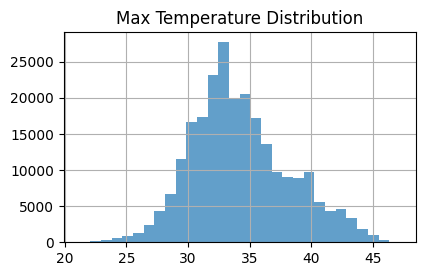

In [ ]:
# Max Temp Histogram
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
df['Max Temp (°C)'].hist(bins=30, alpha=0.7)
plt.title('Max Temperature Distribution')


**Interpretation:** This distribution shows Telangana's hottest daily temperatures dominate between 30°C and 36°C, peaking around 33°C, showing consistent hot, daytime conditions. This pattern reflects a hot, sweaty summers, where high temperatures are common and cooler outliers are rare. The cooler days bring monsoon relief, helping them pinpoint hotter zones for smarter crop planning.

Text(0.5, 1.0, 'Rainfall Distribution')

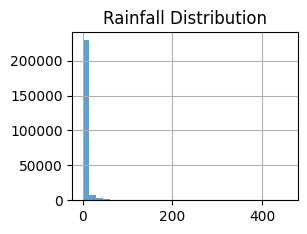

In [ ]:
# Rain Histogram
plt.subplot(2,2,2)
df['Rain (mm)'].hist(bins=30, alpha=0.7)
plt.title('Rainfall Distribution')

**Interpretation:** This histogram shows Telangana's rainfall peaking towards dry days at 0mm with light spread up to 50mm among dry seasons and occasional monsoon days extremes. The dry dominant patterns along with intense rain hotspots is crucial for water usage.

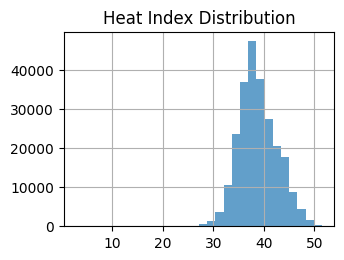

In [ ]:
# Heat Index Histogram
plt.subplot(2,2,3)
df['Heat_Index'].hist(bins=30, alpha=0.7)
plt.title('Heat Index Distribution')

plt.tight_layout()
plt.show()

**Interpretation:** This histogram shows heat index of Telangana, mostly hitting 30 - 40 with extra sweaty summer days that drain us and light presence around 25 - 30. The rare peaks near 50 make the hottest danger zone for targeted climate planning.

In [ ]:
# Monthly summary statistics
monthly_stats = df.groupby('Month')[numeric_cols].mean().round(2)
print("=== MONTHLY AVERAGES ===")
print(monthly_stats.T)  # Transpose for readability

=== MONTHLY AVERAGES ===
Month                  April  August  December  February  January   July  \
Rain (mm)               0.33    6.57      0.50      0.03     0.00   8.92   
Min Temp (°C)          25.18   24.14     18.27     19.23    16.41  24.24   
Max Temp (°C)          40.33   33.12     31.05     34.01    31.49  31.33   
Min Humidity (%)       27.94   68.02     52.43     37.50    42.84  71.58   
Max Humidity (%)       73.23   96.56     94.84     91.17    95.06  95.51   
Min Wind Speed (Kmph)   0.18    0.33      0.08      0.19     0.08   0.96   
Max Wind Speed (Kmph)   8.86    8.71      6.26      7.99     6.84  10.68   
Heat_Index             43.99   37.95     35.79     38.56    36.25  36.11   

Month                   June  March    May  November  October  September  
Rain (mm)               5.19   0.19   2.10      0.18     2.04       9.99  
Min Temp (°C)          25.42  22.32  26.28     17.57    22.72      23.51  
Max Temp (°C)          36.70  36.82  40.26     32.34    34.37    

In [ ]:
print("\n=== SEASONAL EXTREMES ===")
print("Hottest month (Max Temp):")
print(monthly_stats['Max Temp (°C)'].idxmax(), monthly_stats['Max Temp (°C)'].max())
print("Wettest month (Rain):")
print(monthly_stats['Rain (mm)'].idxmax(), monthly_stats['Rain (mm)'].max())



=== SEASONAL EXTREMES ===
Hottest month (Max Temp):
April 40.33
Wettest month (Rain):
September 9.99


# Outliers

In [ ]:
# Detect temperature & rain extremes
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Flag outliers
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
            (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

print("Outlier days:", outliers.sum())
print("Outlier examples:")
print(df[outliers][['District', 'Month', 'Max Temp (°C)', 'Rain (mm)']].head())


Outlier days: 91589
Outlier examples:
    District    Month  Max Temp (°C)  Rain (mm)
17  Adilabad  January           31.7        0.0
24  Adilabad  January           26.2        0.0
27  Adilabad  January           31.8        0.0
70  Adilabad  January           31.8        0.0
86  Adilabad  January           26.1        0.0


# Monthly Weather Trends

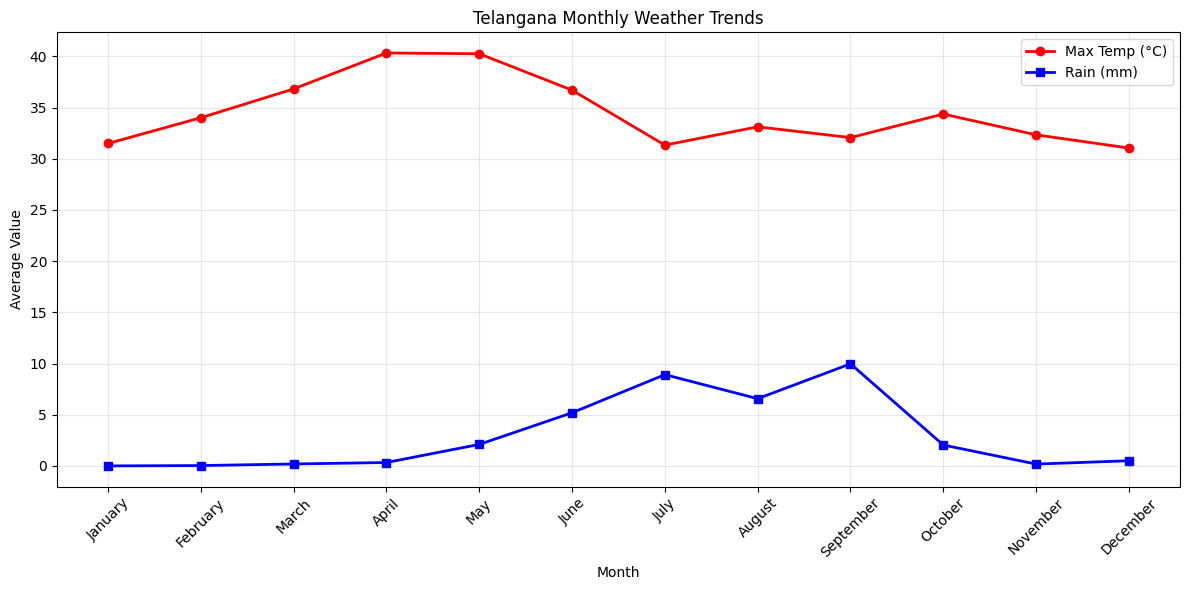

Monthly Averages:
           Max Temp (°C)  Rain (mm)
Month                              
January            31.49       0.00
February           34.01       0.03
March              36.82       0.19
April              40.33       0.33
May                40.26       2.10
June               36.70       5.19
July               31.33       8.92
August             33.12       6.57
September          32.07       9.97
October            34.37       2.04
November           32.34       0.18
December           31.05       0.50


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

monthly_avg = df.groupby('Month')[['Max Temp (°C)', 'Rain (mm)']].mean()
monthly_avg = monthly_avg.reindex(month_order) # Reindex to sort months chronologically

plt.figure(figsize=(12,6))
plt.plot(monthly_avg.index, monthly_avg['Max Temp (°C)'], marker='o', linewidth=2,
         label='Max Temp (°C)', color='red')
plt.plot(monthly_avg.index, monthly_avg['Rain (mm)'], marker='s', linewidth=2,
         label='Rain (mm)', color='blue')
plt.title('Telangana Monthly Weather Trends')
plt.xlabel('Month')
plt.ylabel('Average Value')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_weather_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("Monthly Averages:")
print(monthly_avg.round(2))

**Interpretation:** This line chart shows Telangana's seasonal climate patterns. Maximum temperature peaks around 40°C in April-May marking the most stressful period for summer crops due to rapid moisture loss. As temperatures subside, rainfall  increases from June-September indicating the monsoon season, peaking in September. For agriculture planning, this shows two distinct zones: high irrigation summer and high moisture monsoon where managing field drainage and water loggin becomes the priority.

# 2. Bivariate Analysis

=== CORRELATION MATRIX ===
                       Rain (mm)  Min Temp (°C)  Max Temp (°C)  \
Rain (mm)                   1.00           0.11          -0.14   
Min Temp (°C)               0.11           1.00           0.53   
Max Temp (°C)              -0.14           0.53           1.00   
Min Humidity (%)            0.30           0.20          -0.58   
Max Humidity (%)            0.16          -0.30          -0.53   
Min Wind Speed (Kmph)       0.07           0.10          -0.10   
Max Wind Speed (Kmph)       0.09           0.18           0.08   
Heat_Index                 -0.13           0.52           0.99   

                       Min Humidity (%)  Max Humidity (%)  \
Rain (mm)                          0.30              0.16   
Min Temp (°C)                      0.20             -0.30   
Max Temp (°C)                     -0.58             -0.53   
Min Humidity (%)                   1.00              0.53   
Max Humidity (%)                   0.53              1.00   
Min Wind Spe

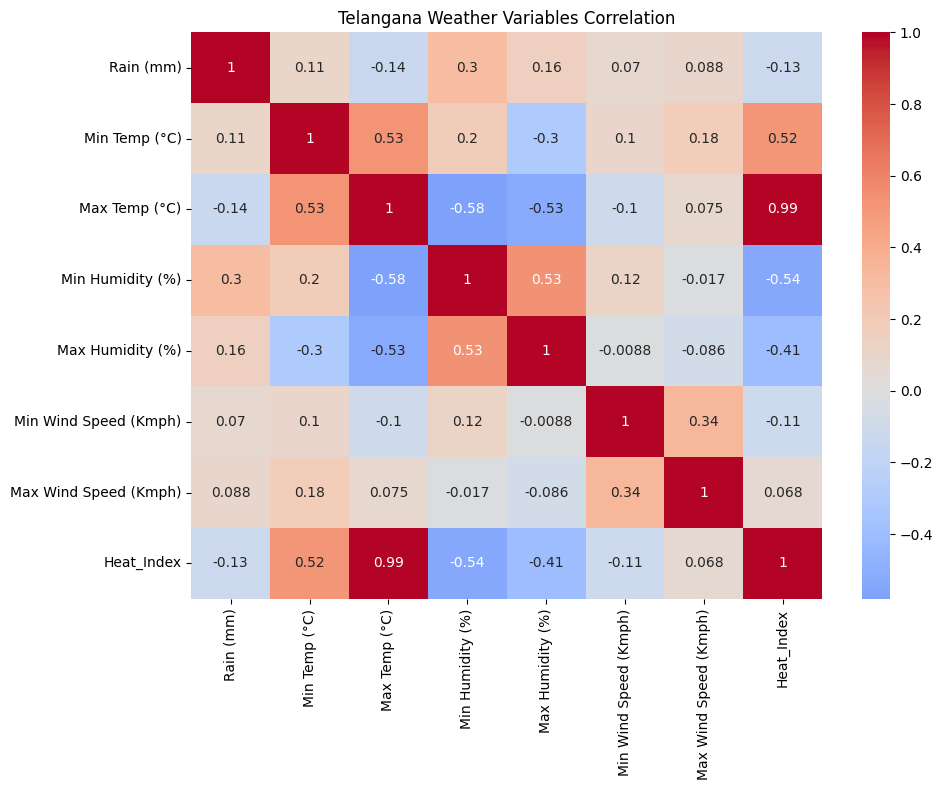

In [ ]:
# Correlation matrix (numeric columns only)
print("=== CORRELATION MATRIX ===")
corr_matrix = df.select_dtypes(include='number').corr()
print(corr_matrix.round(2))

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Telangana Weather Variables Correlation')
plt.tight_layout()
plt.show()


**Interpretation:** This correlation matrix shows that maximum temperature is the primary driver of the heat-index (0.99) making extreme heat the single biggest stressor for local crops. The moderate negative correlation between heat and humidity reveals a double threat as hotter days are generally drier. This proves that for agricultural segmentation, the most critical factor is managing the temperature humidity balance to protect soil moisture and prevent crop wilting.

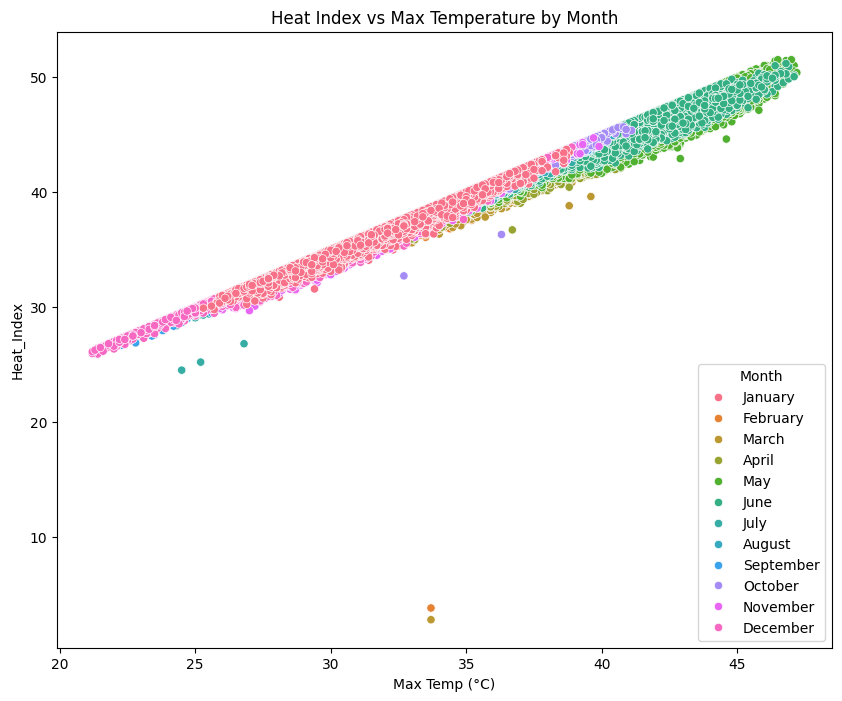

In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df, x='Max Temp (°C)', y='Heat_Index', hue='Month')
plt.title('Heat Index vs Max Temperature by Month')
plt.show()


**Interpretation:** This chart shows that as temperature rises, the heat index reaches dangerous peaks above 50 in May and June. Most of the months follow this pattern, the outliers at 34°C are errors rather than actual weather patterns. This late Q2 period (May-June) is high risk window for agriculture where actual heat stress is much harder on the body than the actual temperature shows.

Text(0.5, 1.0, 'Temp vs Humidity')

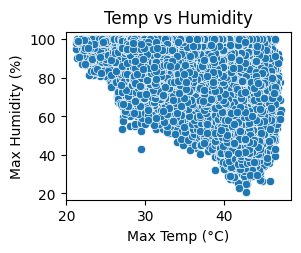

In [ ]:
# Temp vs Humidity Scatter
plt.subplot(2,2,4)
sns.scatterplot(data=df, x='Max Temp (°C)', y='Max Humidity (%)')
plt.title('Temp vs Humidity')


**Interpretation:** This chart shows a wide range of conditions but with a clear pattern: as temperatures rise towards 45°C, humidity level tends to drop though they rarely fall below 20%. The heavy concentration of data at the top (80% - 100% humidity) across all temperatures show high moiture days are very common, regardless of how hot it becomes. The empty space in bottom-left corner shows cool dry days are rare. If cooler day (around 20°C) we can always expect high humidity.

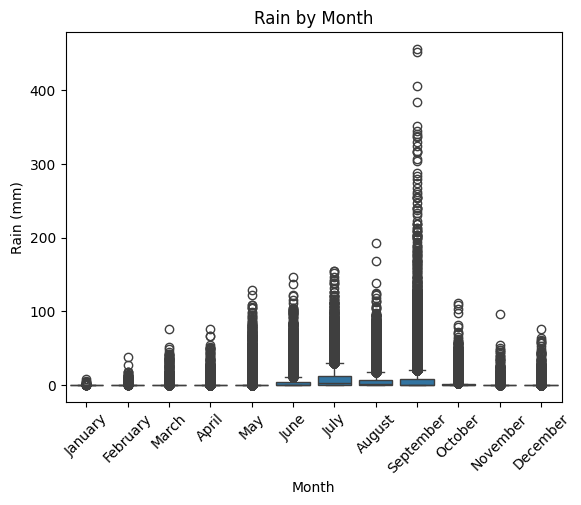

In [ ]:
# Rain vs Humidity Boxplot
sns.boxplot(data=df, x='Month', y='Rain (mm)')
plt.title('Rain by Month')
plt.xticks(rotation=45)
plt.show()

**Interpretation:** The rainfall remains low early in the year but spikes in May reaching peak in September. While July and August have more consistent moisture for crop growth, September is an unpredictable month seeing extreme downpours of nearly 500mm that far exceed the rest of the year. It makes September the critical window where rain transitions from a helpful resource to a high risk for crop damage, soil erosion and harvest disruption.

# District Analysis

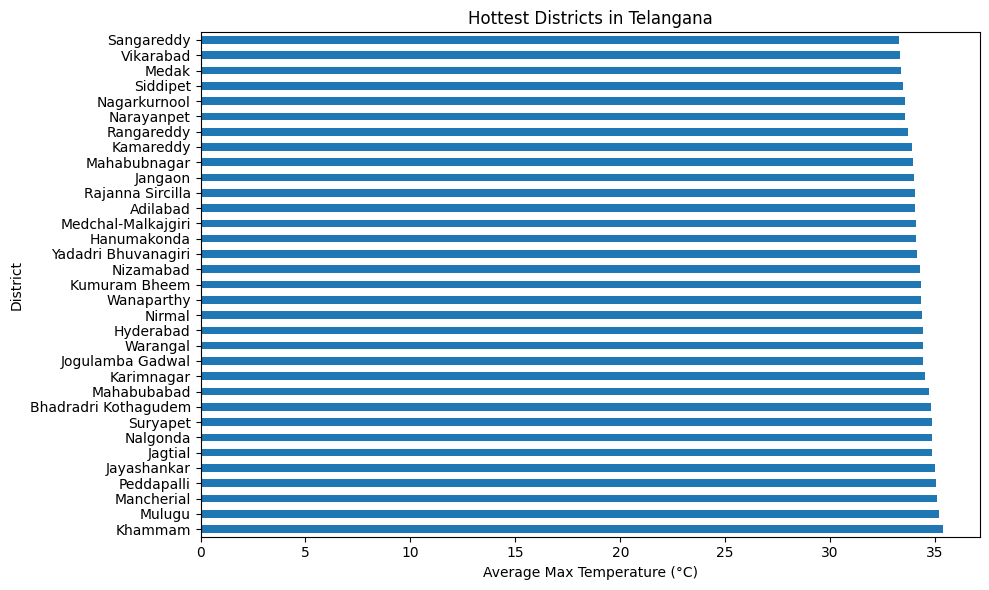

District
Khammam                 35.37
Mulugu                  35.17
Mancherial              35.07
Peddapalli              35.04
Jayashankar             35.00
Jagtial                 34.87
Nalgonda                34.87
Suryapet                34.84
Bhadradri Kothagudem    34.82
Mahabubabad             34.72
Karimnagar              34.53
Jogulamba Gadwal        34.42
Warangal                34.40
Hyderabad               34.40
Nirmal                  34.38
Wanaparthy              34.34
Kumuram Bheem           34.33
Nizamabad               34.28
Yadadri Bhuvanagiri     34.14
Hanumakonda             34.08
Medchal-Malkajgiri      34.08
Adilabad                34.06
Rajanna Sircilla        34.06
Jangaon                 33.98
Mahabubnagar            33.96
Kamareddy               33.92
Rangareddy              33.71
Narayanpet              33.59
Nagarkurnool            33.55
Siddipet                33.49
Medak                   33.37
Vikarabad               33.33
Sangareddy              33.29
N

In [ ]:
district_stats = df.groupby('District')['Max Temp (°C)'].mean().sort_values(ascending=False)
district_stats.plot(kind='barh', figsize=(10,6))
plt.title('Hottest Districts in Telangana')
plt.xlabel('Average Max Temperature (°C)')
plt.tight_layout()
plt.show()
print(district_stats.round(2))


**Interpretation:** This bar chart shows average maximum temperatures are consistent across the region, with all major districts between 33°C and 35.5°C. Khammam and Mulugu are the warmest zones consistently staying above 35°C threshold. Temperature between hottest and coolest districts is about 2°C this slight variation can influence local energy demands. For crop planning, these temperatures suggest that while hottest district require more aggressive irrigation, even the cooler districts like Sangareddy remain high enough to impact soil health and water requirements.

# 3. Multivariate Analysis

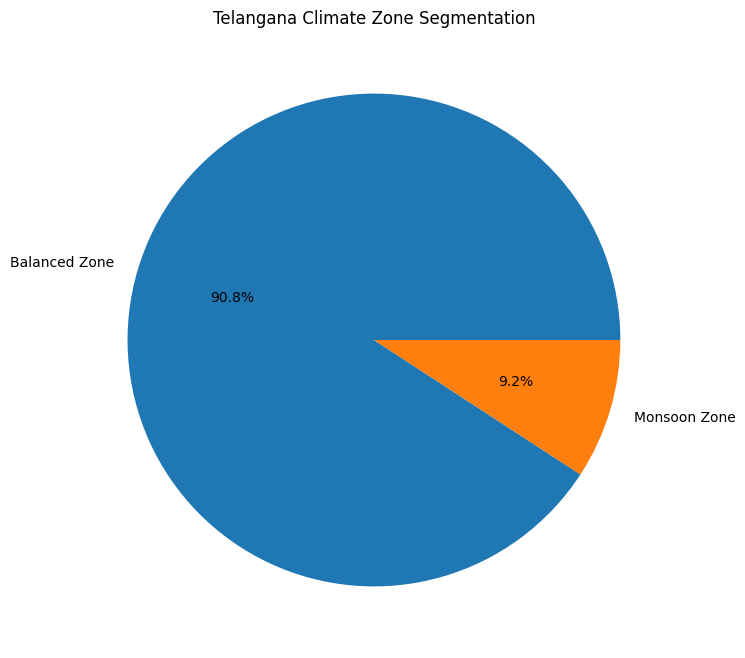

In [ ]:
zone_counts = df['Climate_Zone'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(zone_counts.values, labels=zone_counts.index, autopct='%1.1f%%')
plt.title('Telangana Climate Zone Segmentation')
plt.show()


**Interpretation:** This pie chart shows two distinct agricultural profiles: the Balanced Zone (90.8%) and the Monsoon Zone (9.2%). For the majority of the region, the focus must remain on versatile irrigation to mitigate consistent heat stress. The smaller Monsoon zone marks high priority areas requiring drainage infrastructure and flood resistant crops to survive extreme September. This approach ensures that water management and crop selection are precise to local climate's real world risks.

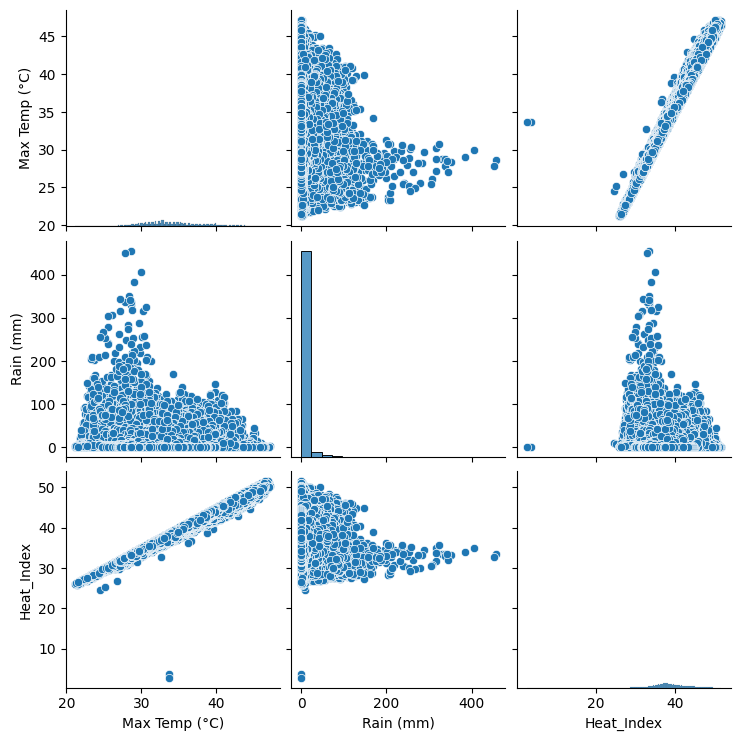

In [ ]:
# Pairplot
sns.pairplot(df[['Max Temp (°C)', 'Rain (mm)', 'Heat_Index']], diag_kind='hist')
plt.show()

**Interpretation:** The chart connects heat, rain and humidity. It clearly shows heat is the main driver for crop stress but the rainfall bars show occasional floods, dry days are the daily reality for most farmers. While the outliers at 34°C are errors, rest of the data shows a clear transistion. For a farmer, this critical shift from surviving summer heat to managing monsoon moisture.

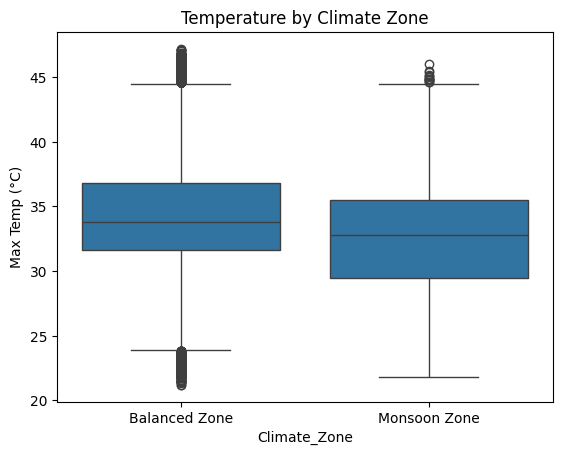

In [ ]:
# Climate Zone profiles
sns.boxplot(data=df, x='Climate_Zone', y='Max Temp (°C)')
plt.title('Temperature by Climate Zone')
plt.show()

**Interpretation:** This boxplot shows the thermal stability of our two regions. The balanced zone is consistently warmer, while monsoon zone shows a lower, wider temperature range due to the cooling effect of rain. Although their averages differ, both zones share identical extreme peaks, proving that heat protection is a universal requirement across Telangana.